--- Contoh Tweet Mentah ---
0    Our Deeds are the Reason of this #earthquake M...
1               Forest fire near La Ronge Sask. Canada
2    All residents asked to 'shelter in place' are ...
3    13,000 people receive #wildfires evacuation or...
4    Just got sent this photo from Ruby #Alaska as ...
Name: text, dtype: object


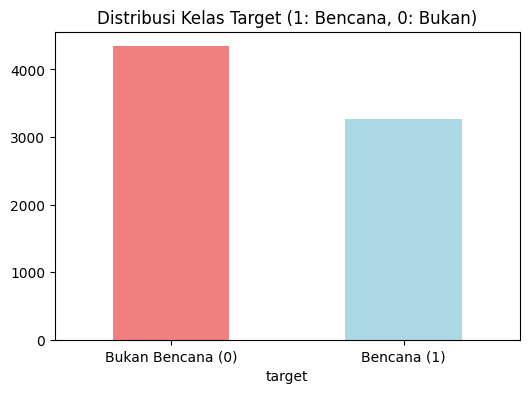


Shape Training Text: (6090,)
Shape Validation Text: (1523,)


In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Memuat dataset (Pastikan file sudah di-rename agar tidak tertukar)
df_nlp = pd.read_csv('train-kasus3.csv')

print("--- Contoh Tweet Mentah ---")
print(df_nlp['text'].head())

# 1. FUNGSI TEXT PREPROCESSING
def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Menghapus URL
    text = re.sub(r'\@\w+|\#', '', text) # Menghapus mention (@) dan tanda hashtag (#), tapi biarkan kata-nya
    text = re.sub(r'[^a-z\s]', '', text) # Menghapus tanda baca dan angka
    text = text.strip()
    return text

# Menerapkan pembersihan ke kolom text
df_nlp['clean_text'] = df_nlp['text'].apply(clean_text)

# 2. EKSPLORASI DATA (EDA)
plt.figure(figsize=(6, 4))
df_nlp['target'].value_counts().plot(kind='bar', color=['lightcoral', 'lightblue'])
plt.title('Distribusi Kelas Target (1: Bencana, 0: Bukan)')
plt.xticks(ticks=[0, 1], labels=['Bukan Bencana (0)', 'Bencana (1)'], rotation=0)
plt.show()

# 3. PEMBAGIAN DATA (Train dan Validation Set)
X_train_nlp, X_val_nlp, y_train_nlp, y_val_nlp = train_test_split(
    df_nlp['clean_text'], df_nlp['target'], test_size=0.2, random_state=42, stratify=df_nlp['target']
)

print(f"\nShape Training Text: {X_train_nlp.shape}")
print(f"Shape Validation Text: {X_val_nlp.shape}")

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report
import time

print("--- Ekstraksi Fitur TF-IDF (Unigram & Bigram) ---")
# Maksimal fitur dibatasi agar RAM tidak penuh dan menghindari overfitting parah
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train_nlp)
X_val_tfidf = tfidf.transform(X_val_nlp)

print(f"Dimensi TF-IDF: {X_train_tfidf.shape}\n")


# 1. LOGISTIC REGRESSION
print("--- Training Logistic Regression ---")
start_time_lr_nlp = time.time()

lr_nlp = LogisticRegression(max_iter=1000, random_state=42)
lr_nlp.fit(X_train_tfidf, y_train_nlp)

time_lr_nlp = time.time() - start_time_lr_nlp

y_pred_lr_nlp = lr_nlp.predict(X_val_tfidf)
f1_lr_nlp = f1_score(y_val_nlp, y_pred_lr_nlp)

print(f"Waktu Training LR: {time_lr_nlp:.2f} detik")
print(f"F1-Score LR: {f1_lr_nlp:.4f}\n")

# 2. MULTINOMIAL NAIVE BAYES
print("--- Training Multinomial Naive Bayes ---")
start_time_mnb = time.time()

mnb_nlp = MultinomialNB()
mnb_nlp.fit(X_train_tfidf, y_train_nlp)

time_mnb = time.time() - start_time_mnb

y_pred_mnb = mnb_nlp.predict(X_val_tfidf)
f1_mnb = f1_score(y_val_nlp, y_pred_mnb)

print(f"Waktu Training MNB: {time_mnb:.2f} detik")
print(f"F1-Score MNB: {f1_mnb:.4f}\n")

--- Ekstraksi Fitur TF-IDF (Unigram & Bigram) ---
Dimensi TF-IDF: (6090, 10000)

--- Training Logistic Regression ---
Waktu Training LR: 1.11 detik
F1-Score LR: 0.7639

--- Training Multinomial Naive Bayes ---
Waktu Training MNB: 0.02 detik
F1-Score MNB: 0.7535



In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report
import time

print("--- Ekstraksi Fitur TF-IDF (Unigram & Bigram) ---")
# Maksimal fitur dibatasi agar RAM tidak penuh dan menghindari overfitting parah
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train_nlp)
X_val_tfidf = tfidf.transform(X_val_nlp)

print(f"Dimensi TF-IDF: {X_train_tfidf.shape}\n")

# 1. LOGISTIC REGRESSION
print("--- Training Logistic Regression ---")
start_time_lr_nlp = time.time()

lr_nlp = LogisticRegression(max_iter=1000, random_state=42)
lr_nlp.fit(X_train_tfidf, y_train_nlp)

time_lr_nlp = time.time() - start_time_lr_nlp

y_pred_lr_nlp = lr_nlp.predict(X_val_tfidf)
f1_lr_nlp = f1_score(y_val_nlp, y_pred_lr_nlp)

print(f"Waktu Training LR: {time_lr_nlp:.2f} detik")
print(f"F1-Score LR: {f1_lr_nlp:.4f}\n")

# 2. MULTINOMIAL NAIVE BAYES
print("--- Training Multinomial Naive Bayes ---")
start_time_mnb = time.time()

mnb_nlp = MultinomialNB()
mnb_nlp.fit(X_train_tfidf, y_train_nlp)

time_mnb = time.time() - start_time_mnb

y_pred_mnb = mnb_nlp.predict(X_val_tfidf)
f1_mnb = f1_score(y_val_nlp, y_pred_mnb)

print(f"Waktu Training MNB: {time_mnb:.2f} detik")
print(f"F1-Score MNB: {f1_mnb:.4f}\n")

--- Ekstraksi Fitur TF-IDF (Unigram & Bigram) ---
Dimensi TF-IDF: (6090, 10000)

--- Training Logistic Regression ---
Waktu Training LR: 0.05 detik
F1-Score LR: 0.7639

--- Training Multinomial Naive Bayes ---
Waktu Training MNB: 0.00 detik
F1-Score MNB: 0.7535



In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Set seed untuk reproducibility
tf.random.set_seed(42)

print("--- Preprocessing Teks untuk Deep Learning ---")
# 1. Tokenisasi (Mengubah kata menjadi angka index)
max_vocab = 10000 # Maksimal kosakata yang diingat
max_length = 30   # Maksimal panjang kata dalam 1 tweet (rata-rata tweet pendek)

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_nlp)

# 2. Mengubah teks menjadi sekuens angka
X_train_seq = tokenizer.texts_to_sequences(X_train_nlp)
X_val_seq = tokenizer.texts_to_sequences(X_val_nlp)

# 3. Padding (Menyamakan panjang semua sekuens menjadi max_length)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')

print(f"Shape Data Training Pad: {X_train_pad.shape}")

# 4. MEMBANGUN ARSITEKTUR BiLSTM
model_lstm = Sequential([
    # Layer Embedding: Mengubah index kata menjadi vektor padat yang memiliki makna (konteks)
    Embedding(input_dim=max_vocab, output_dim=64, input_length=max_length),

    # Layer Bidirectional LSTM
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5), # Regularisasi untuk mencegah overfitting

    # Fully Connected Layer
    Dense(32, activation='relu'),
    Dropout(0.5),

    # Output Layer (Binary Classification: Bencana atau Bukan)
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop_nlp = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n--- Training Deep Learning (BiLSTM) ---")
start_time_lstm = time.time()

history_lstm = model_lstm.fit(X_train_pad, y_train_nlp,
                              epochs=10,
                              batch_size=32,
                              validation_data=(X_val_pad, y_val_nlp),
                              callbacks=[early_stop_nlp],
                              verbose=1)

time_lstm = time.time() - start_time_lstm

# 5. Evaluasi F1-Score (Syarat Resmi Evaluasi UTS)
# Output sigmoid adalah probabilitas, ubah ke 0 atau 1 dengan threshold 0.5
y_pred_lstm_prob = model_lstm.predict(X_val_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

f1_lstm = f1_score(y_val_nlp, y_pred_lstm)

print(f"\nWaktu Training BiLSTM: {time_lstm:.2f} detik")
print(f"F1-Score BiLSTM: {f1_lstm:.4f}")
print(f"Total Parameter: {model_lstm.count_params()}")

--- Preprocessing Teks untuk Deep Learning ---
Shape Data Training Pad: (6090, 30)

--- Training Deep Learning (BiLSTM) ---
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.6939 - loss: 0.5840 - val_accuracy: 0.8030 - val_loss: 0.4513
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8545 - loss: 0.3579 - val_accuracy: 0.7846 - val_loss: 0.5152
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9020 - loss: 0.2569 - val_accuracy: 0.7768 - val_loss: 0.5848
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9332 - loss: 0.1916 - val_accuracy: 0.7571 - val_loss: 0.6756
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Waktu Training BiLSTM: 37.05 detik
F1-Score BiLSTM: 0.7557
Total Parameter: 710209


In [6]:
# 1. Membuat Tabel Perbandingan Kasus 3
results_nlp = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Naive Bayes (TF-IDF)', 'BiLSTM (Embedding)'],
    'F1-Score (Validation)': [f1_lr_nlp, f1_mnb, f1_lstm],
    'Training Time (s)': [time_lr_nlp, time_mnb, time_lstm]
})

print("--- TABEL PERBANDINGAN KASUS 3 (NLP) ---")
display(results_nlp)

# 2. Analisis Error: Mencari Tweet yang Gagal Diklasifikasi
# Mencari index di mana BiLSTM salah prediksi
errors_idx_nlp = np.where(y_val_nlp.values != y_pred_lstm)[0]

print("\n--- CONTOH TWEET YANG SALAH DIPREDIKSI OLEH BiLSTM ---")
print("Catatan: Target=1 (Bencana Asli), Target=0 (Bukan Bencana/Metafora)")

# Menampilkan 5 contoh kesalahan
count = 0
for idx in errors_idx_nlp:
    actual = y_val_nlp.values[idx]
    pred = y_pred_lstm[idx]
    text = X_val_nlp.iloc[idx]

    # Tampilkan hanya jika teksnya cukup panjang untuk dianalisis
    if len(text.split()) > 5:
        print(f"\n[{count+1}] Teks: '{text}'")
        print(f"    Asli: {actual} | Prediksi: {pred}")
        count += 1
    if count == 5:
        break

--- TABEL PERBANDINGAN KASUS 3 (NLP) ---


,Model,F1-Score (Validation),Training Time (s)
0,Logistic Regression (TF-IDF),0.763877,0.053520
1,Naive Bayes (TF-IDF),0.753521,0.004558
2,BiLSTM (Embedding),0.755700,37.054626



--- CONTOH TWEET YANG SALAH DIPREDIKSI OLEH BiLSTM ---
Catatan: Target=1 (Bencana Asli), Target=0 (Bukan Bencana/Metafora)

[1] Teks: 'ted cruz fires back at jeb amp bush we lose because of republicans like jeb amp mitt video'
    Asli: 0 | Prediksi: 1

[2] Teks: 'hollywood movie about trapped miners released in chile the  hollywood movie about trapped miners starring'
    Asli: 1 | Prediksi: 0

[3] Teks: 'i cant drown my demons they know how to swim'
    Asli: 1 | Prediksi: 0

[4] Teks: 'we need these plants in the pacific during the cyclone seasons it would help'
    Asli: 1 | Prediksi: 0

[5] Teks: 'if firefighters acted like cops theyd drive around shooting a flamethrower at burning buildings'
    Asli: 0 | Prediksi: 1
